In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')

In [4]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


In [5]:
df.shape

(10841, 13)

In [6]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [7]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [9]:
df_cpy = df.copy()

## Handling Review column

In [10]:
# df['Reviews'].astype(int)

In [11]:
df['Reviews'].str.isnumeric().value_counts()

Reviews
True     10840
False        1
Name: count, dtype: int64

In [12]:
df[~df['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [13]:
df['Reviews'].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'],
      shape=(6002,), dtype=object)

In [14]:
df_cpy = df.drop(index = 10472)

In [15]:
df_cpy['Reviews'] = df_cpy['Reviews'].astype(int)

In [16]:
df_cpy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  object 
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.2+ MB


In [17]:
df_cpy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


## Handling column size

In [18]:
df_cpy['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [19]:
df_cpy['Size'] = df_cpy['Size'].str.replace('M', '000000')
df_cpy['Size'] = df_cpy['Size'].str.replace('k', '000')

In [20]:
df_cpy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7000000,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8000000,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [21]:
df_cpy['Size'] = df_cpy['Size'].replace('Varies with device', np.nan)

In [22]:
df_cpy['Size'] = df_cpy['Size'].astype(float)

In [23]:
df_cpy['Size'] = df_cpy['Size'].fillna(df_cpy['Size'].mean())

In [24]:
df_cpy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


In [25]:
df_cpy['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [26]:
df_cpy['Installs'] = df_cpy['Installs'].str.split('+').str[0]

In [27]:
df_cpy['Installs']= df_cpy['Installs'].str.replace(',', '')

In [28]:
df_cpy['Installs'] = df_cpy['Installs'].astype(int)

In [29]:
df_cpy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 1.2+ MB


In [30]:
df_cpy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


## Handling Price Column

In [31]:
df_cpy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 1.2+ MB


In [32]:
df_cpy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


In [33]:
df['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', 'Everyone', '$1.20', '$1.04'], dtype=object)

In [34]:
df_cpy['Price'] = df_cpy['Price'].str.replace('$', '')

In [35]:
df_cpy['Price'] = df_cpy['Price'].astype(float)

In [36]:
df_cpy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 1.2+ MB


In [37]:
df_cpy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


## Last Updated Column

In [38]:
df_cpy['Last Updated'].unique()

array(['January 7, 2018', 'January 15, 2018', 'August 1, 2018', ...,
       'January 20, 2014', 'February 16, 2014', 'March 23, 2014'],
      shape=(1377,), dtype=object)

In [39]:
df_cpy['Last Updated'] = df_cpy['Last Updated'].str.replace(',','')

In [40]:
df_cpy['Date_updated'] = df_cpy['Last Updated'].str.split(' ').str[1]
df_cpy['Month_updated'] = df_cpy['Last Updated'].str.split(' ').str[0]
df_cpy['Year_updated'] = df_cpy['Last Updated'].str.split(' ').str[2]

In [41]:
df_cpy['Month_updated'] = df_cpy['Month_updated'].map({
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12
})

In [42]:
df_cpy['Year_updated'] = df_cpy['Year_updated'].astype(int)
df_cpy['Date_updated'] = df_cpy['Date_updated'].astype(int)

In [43]:
df_cpy.drop('Last Updated', axis = 1, inplace = True)

In [44]:
df_cpy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Current Ver     10832 non-null  object 
 11  Android Ver     10838 non-null  object 
 12  Date_updated    10840 non-null  int64  
 13  Month_updated   10840 non-null  int64  
 14  Year_updated    10840 non-null  int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 1.3+ MB


In [45]:
df_cpy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Date_updated,Month_updated,Year_updated
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,Free,0.0,Everyone,Art & Design,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2.0.0,4.0.3 and up,15,1,2018


## Handling Type column

In [46]:
df_cpy['Type'].unique()

array(['Free', 'Paid', nan], dtype=object)

In [47]:
df_cpy['Type'].isnull().sum()

np.int64(1)

In [48]:
df_cpy[df_cpy['Type'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Date_updated,Month_updated,Year_updated
9148,Command & Conquer: Rivals,FAMILY,NaN,0,1.957748e+07,0,NaN,0.0,Everyone 10+,Strategy,Varies with device,Varies with device,28,6,2018


In [49]:
df_cpy['Type'].fillna(df_cpy['Type'].mode()[0], inplace = True)

C:\Users\Lalit Chandra\AppData\Local\Temp\ipykernel_24192\3099285111.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cpy['Type'].fillna(df_cpy['Type'].mode()[0], inplace = True)


In [50]:
df_cpy['Type'].isnull().sum()

np.int64(0)

In [51]:
df_cpy['Type'].value_counts()

Type
Free    10040
Paid      800
Name: count, dtype: int64

In [55]:
from sklearn.utils import resample

In [56]:
df_cpy_free = df_cpy[df_cpy['Type'] == 'Free']
df_cpy_paid = df_cpy[df_cpy['Type'] == 'Paid']

In [60]:
df_paid_upsampled = resample(
    df_cpy_paid,
    replace=True,                
    n_samples=len(df_cpy_free),         
    random_state=42)

In [73]:
df_cpy = pd.concat([df_cpy_free, df_paid_upsampled])

In [80]:
df_cpy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Date_updated,Month_updated,Year_updated
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,Free,0.0,Everyone,Art & Design,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2.0.0,4.0.3 and up,15,1,2018


In [78]:
df_cpy['Type'].value_counts()

Type
Free    10040
Paid    10040
Name: count, dtype: int64

In [81]:
df_cpy['Type'] = df_cpy['Type'].map({'Free': 1, 'Paid' : 2})

In [82]:
df_cpy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20080 entries, 0 to 4559
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             20080 non-null  object 
 1   Category        20080 non-null  object 
 2   Rating          16886 non-null  float64
 3   Reviews         20080 non-null  int64  
 4   Size            20080 non-null  float64
 5   Installs        20080 non-null  int64  
 6   Type            20080 non-null  int64  
 7   Price           20080 non-null  float64
 8   Content Rating  20080 non-null  object 
 9   Genres          20080 non-null  object 
 10  Current Ver     20054 non-null  object 
 11  Android Ver     20064 non-null  object 
 12  Date_updated    20080 non-null  int64  
 13  Month_updated   20080 non-null  int64  
 14  Year_updated    20080 non-null  int64  
dtypes: float64(3), int64(6), object(6)
memory usage: 2.5+ MB


In [83]:
df_cpy.to_csv('EDA Google Playstore.csv')

In [84]:
df_cpy[df_cpy.duplicated('App')]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Date_updated,Month_updated,Year_updated
229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,1.957748e+07,5000000,1,0.00,Everyone,Business,Varies with device,4.0.3 and up,26,2,2018
236,Box,BUSINESS,4.2,159872,1.957748e+07,10000000,1,0.00,Everyone,Business,Varies with device,Varies with device,31,7,2018
239,Google My Business,BUSINESS,4.4,70991,1.957748e+07,5000000,1,0.00,Everyone,Business,2.19.0.204537701,4.4 and up,24,7,2018
256,ZOOM Cloud Meetings,BUSINESS,4.4,31614,3.700000e+07,10000000,1,0.00,Everyone,Business,4.1.28165.0716,4.0 and up,20,7,2018
261,join.me - Simple Meetings,BUSINESS,4.0,6989,1.957748e+07,1000000,1,0.00,Everyone,Business,4.3.0.508,4.4 and up,16,7,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7183,Билеты ПДД CD 2019 PRO,AUTO_AND_VEHICLES,NaN,21,1.600000e+07,100,2,1.49,Everyone,Auto & Vehicles,1.49,4.0 and up,27,7,2018
5036,NewTek NDI,PHOTOGRAPHY,3.5,77,1.200000e+00,1000,2,19.99,Everyone,Photography,1.1,4.1 and up,26,10,2016
2262,Super Hearing Secret Voices Recorder PRO,MEDICAL,5.0,3,2.300000e+07,100,2,2.99,Everyone,Medical,1.0,4.1 and up,20,4,2018
4901,Assassin's Creed Identity,GAME,3.7,42529,9.200000e+07,500000,2,1.99,Teen,Action,2.8.2,4.1 and up,23,11,2016


In [85]:
df_cpy.drop_duplicates(subset = ['App'],keep= 'first',inplace = True)

In [86]:
df_cpy['App'].unique()

array(['Photo Editor & Candy Camera & Grid & ScrapBook',
       'Coloring book moana',
       'U Launcher Lite – FREE Live Cool Themes, Hide Apps', ...,
       'THE aMAZEing Labyrinth', 'Organizer', 'RETRO Shocked DW-6000'],
      shape=(9659,), dtype=object)

In [87]:
df_cpy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9659 entries, 0 to 9010
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9659 non-null   object 
 1   Category        9659 non-null   object 
 2   Rating          8196 non-null   float64
 3   Reviews         9659 non-null   int64  
 4   Size            9659 non-null   float64
 5   Installs        9659 non-null   int64  
 6   Type            9659 non-null   int64  
 7   Price           9659 non-null   float64
 8   Content Rating  9659 non-null   object 
 9   Genres          9659 non-null   object 
 10  Current Ver     9651 non-null   object 
 11  Android Ver     9657 non-null   object 
 12  Date_updated    9659 non-null   int64  
 13  Month_updated   9659 non-null   int64  
 14  Year_updated    9659 non-null   int64  
dtypes: float64(3), int64(6), object(6)
memory usage: 1.2+ MB


In [88]:
cate = pd.DataFrame(df_cpy['Category'].value_counts())

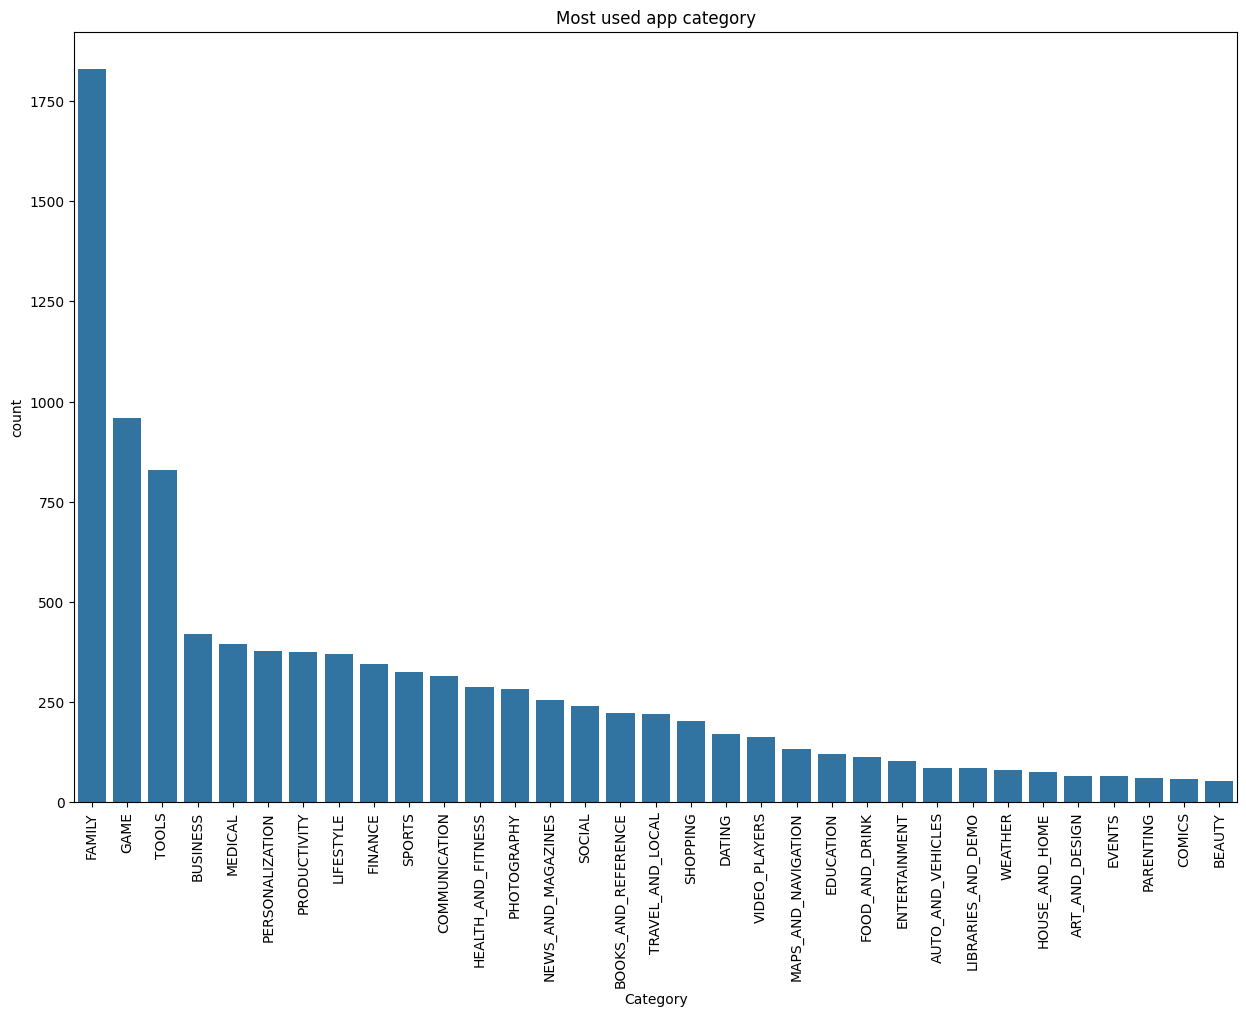

In [89]:
plt.figure(figsize = (15,10)) 
sns.barplot(df_cpy['Category'].value_counts())
plt.title(label = 'Most used app category')
plt.xticks(rotation = 90)
plt.show()

In [90]:
df_cpy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9659 entries, 0 to 9010
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9659 non-null   object 
 1   Category        9659 non-null   object 
 2   Rating          8196 non-null   float64
 3   Reviews         9659 non-null   int64  
 4   Size            9659 non-null   float64
 5   Installs        9659 non-null   int64  
 6   Type            9659 non-null   int64  
 7   Price           9659 non-null   float64
 8   Content Rating  9659 non-null   object 
 9   Genres          9659 non-null   object 
 10  Current Ver     9651 non-null   object 
 11  Android Ver     9657 non-null   object 
 12  Date_updated    9659 non-null   int64  
 13  Month_updated   9659 non-null   int64  
 14  Year_updated    9659 non-null   int64  
dtypes: float64(3), int64(6), object(6)
memory usage: 1.2+ MB


In [91]:
cate_installs = pd.DataFrame(df_cpy.groupby('Category')['Installs'].sum())

In [92]:
cate_installs.head()

,Installs
Category,
ART_AND_DESIGN,114338100
AUTO_AND_VEHICLES,53130211
BEAUTY,27197050
BOOKS_AND_REFERENCE,1665969576
BUSINESS,697164865


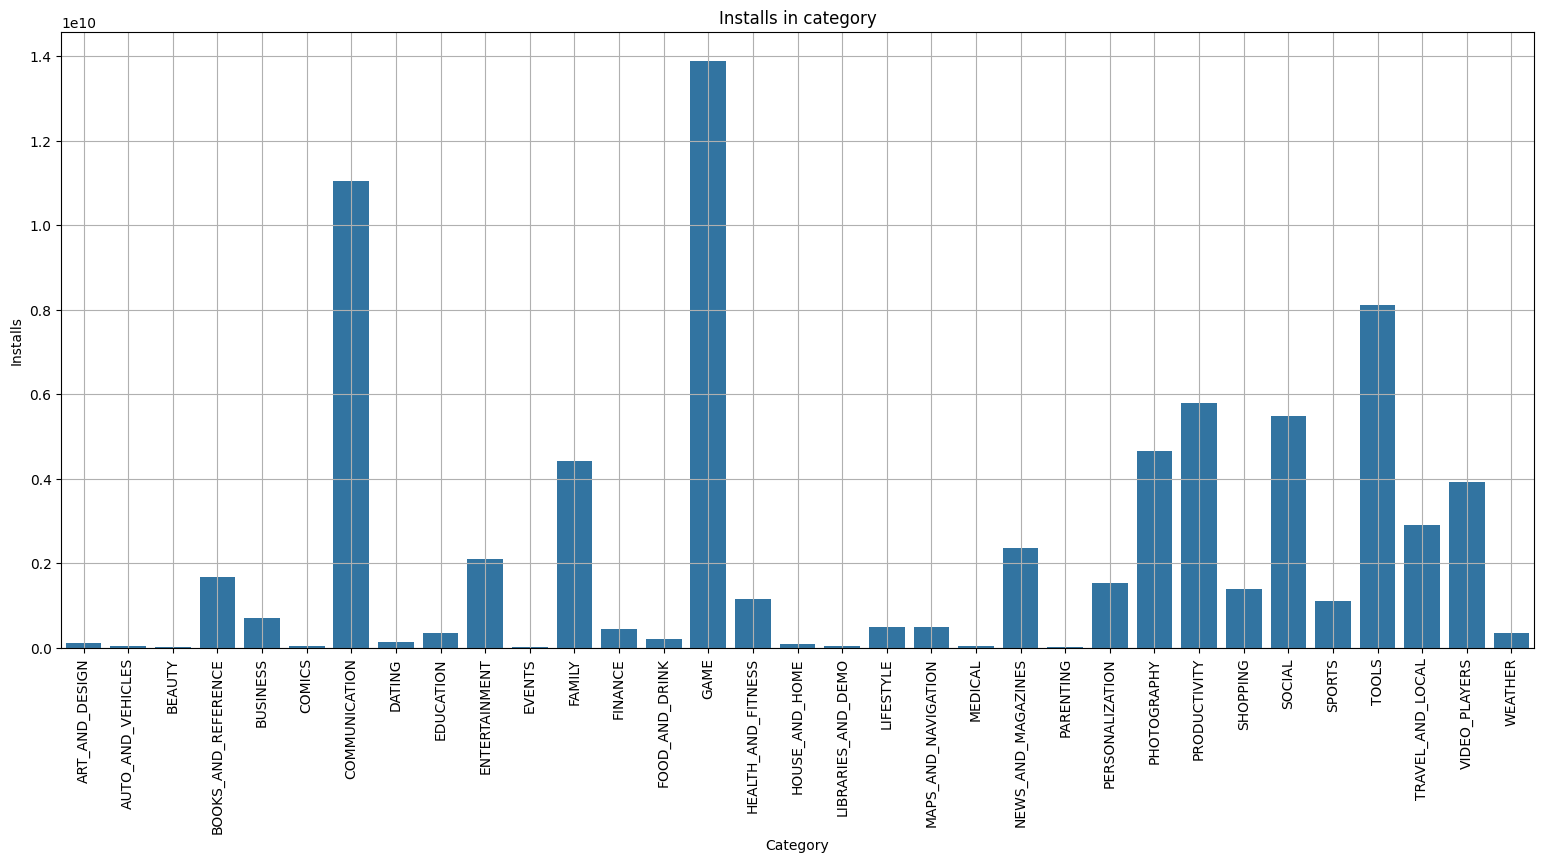

In [93]:
plt.figure(figsize = (19,8))
sns.barplot(data = cate_installs, x = 'Category', y = 'Installs')
plt.title(label = 'Installs in category')
plt.xticks(rotation = 90)
plt.grid()
plt.show()

In [95]:
df_cpy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Date_updated,Month_updated,Year_updated
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,1,0.0,Everyone,Art & Design,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,1,0.0,Everyone,Art & Design;Pretend Play,2.0.0,4.0.3 and up,15,1,2018


In [106]:
df_cpy_cateappinstalls = pd.DataFrame(df_cpy.groupby(['Category','App'])['Installs'].sum())

In [107]:
df_cpy_cateappinstalls

Installs
Category       App                                                         
ART_AND_DESIGN 350 Diy Room Decor Ideas                               10000
               3D Color Pixel by Number - Sandbox Art Coloring       100000
               AJ Styles HD Wallpapers                                 5000
               AJ Styles Wallpaper 2018 - AJ Styles HD Wallpaper       1000
               Ai illustrator viewer                                 100000
...                                                                     ...
WEATHER        Yahoo Weather                                       10000000
               Yahoo! Weather for SH Forecast for understandin...   1000000
               Yandex.Weather                                      10000000
               weather - weather forecast                           1000000
               wetter.com - Weather and Radar                      10000000

[9659 rows x 1 columns]